<a href="https://colab.research.google.com/github/sevenZHQ1018/Econ5200/blob/lab/Class15_Lab15_hangqi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1: 数据摄入与可视化探索性数据分析 (EDA)

In [1]:
# Step 1: 导入所需库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

# 摄入现代化NVIDIA数据集（反映2024-2026年AI基础设施支出繁荣）
data = {
    'Time_Index': np.array([1, 2, 3, 4, 5, 6, 7, 8]),
    'Total_Revenue_Billions': np.array([26.04, 30.04, 35.10, 39.33, 44.06, 46.74, 57.00, 68.10])
}
df = pd.DataFrame(data)
X = df[['Time_Index']]
y = df['Total_Revenue_Billions']

print('NVIDIA 数据集预览:')
print(df.to_string(index=False))

NVIDIA 数据集预览:
 Time_Index  Total_Revenue_Billions
          1                   26.04
          2                   30.04
          3                   35.10
          4                   39.33
          5                   44.06
          6                   46.74
          7                   57.00
          8                   68.10


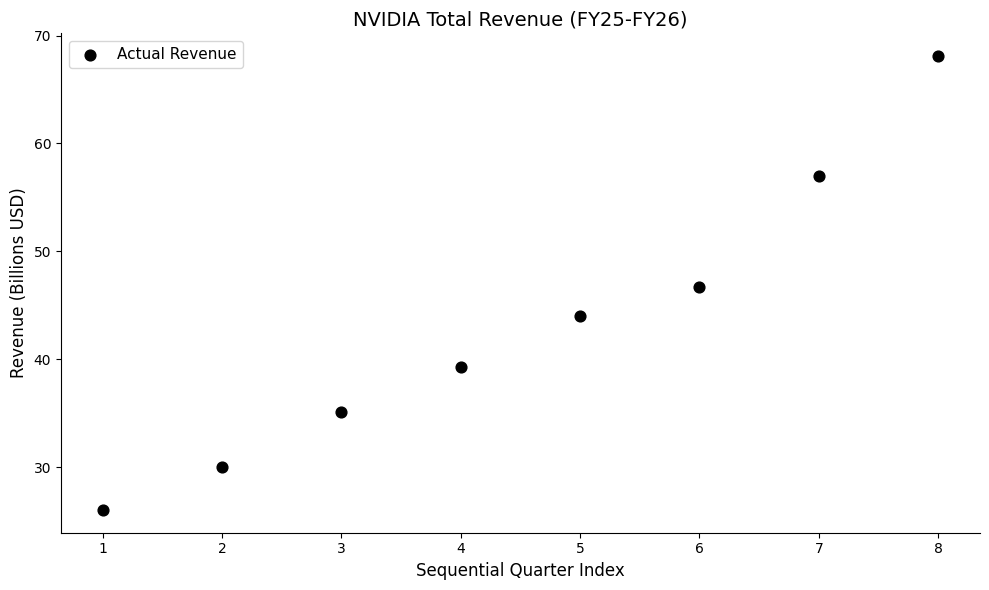

EDA观察：营收呈现明显的非线性指数增长趋势，简单线性模型将系统性低估高增长阶段。


In [2]:
# 可视化EDA：散点图（遵循数据墨水比原则）
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', zorder=5, label='Actual Revenue', s=60)
plt.title('NVIDIA Total Revenue (FY25-FY26)', fontsize=14)
plt.xlabel('Sequential Quarter Index', fontsize=12)
plt.ylabel('Revenue (Billions USD)', fontsize=12)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print('EDA观察：营收呈现明显的非线性指数增长趋势，简单线性模型将系统性低估高增长阶段。')

## Step 2: 高偏差模型（欠拟合）—— 线性回归基准

In [3]:
# Step 2: 高偏差（欠拟合）线性模型
lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_pred_linear = lin_reg.predict(X)
mse_linear = mean_squared_error(y, y_pred_linear)

print(f'Linear Training MSE (High Bias): {mse_linear:.4f}')
print(f'线性系数: beta1={lin_reg.coef_[0]:.4f}, 截距 beta0={lin_reg.intercept_:.4f}')
print('解读：直线无法捕捉非线性指数增长，产生系统性偏差（欠拟合）。')

Linear Training MSE (High Bias): 7.9139
线性系数: beta1=5.5818, 截距 beta0=18.1832
解读：直线无法捕捉非线性指数增长，产生系统性偏差（欠拟合）。


## Step 3: 高方差模型（过拟合）—— 7阶多项式回归

In [4]:
# Step 3: 高方差（过拟合）7阶多项式模型
poly_features = PolynomialFeatures(degree=7, include_bias=False)
X_poly = poly_features.fit_transform(X)

poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)
y_pred_poly = poly_reg.predict(X_poly)
mse_poly = mean_squared_error(y, y_pred_poly)

print(f'Polynomial Degree-7 Training MSE (High Variance): {mse_poly:.8f}')
print(f'对比 - 线性训练MSE: {mse_linear:.4f}')
print('解读：训练MSE接近零——模型已记忆了每一个噪声点，而非学习真正的经济规律。')

Polynomial Degree-7 Training MSE (High Variance): 0.00000000
对比 - 线性训练MSE: 7.9139
解读：训练MSE接近零——模型已记忆了每一个噪声点，而非学习真正的经济规律。


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


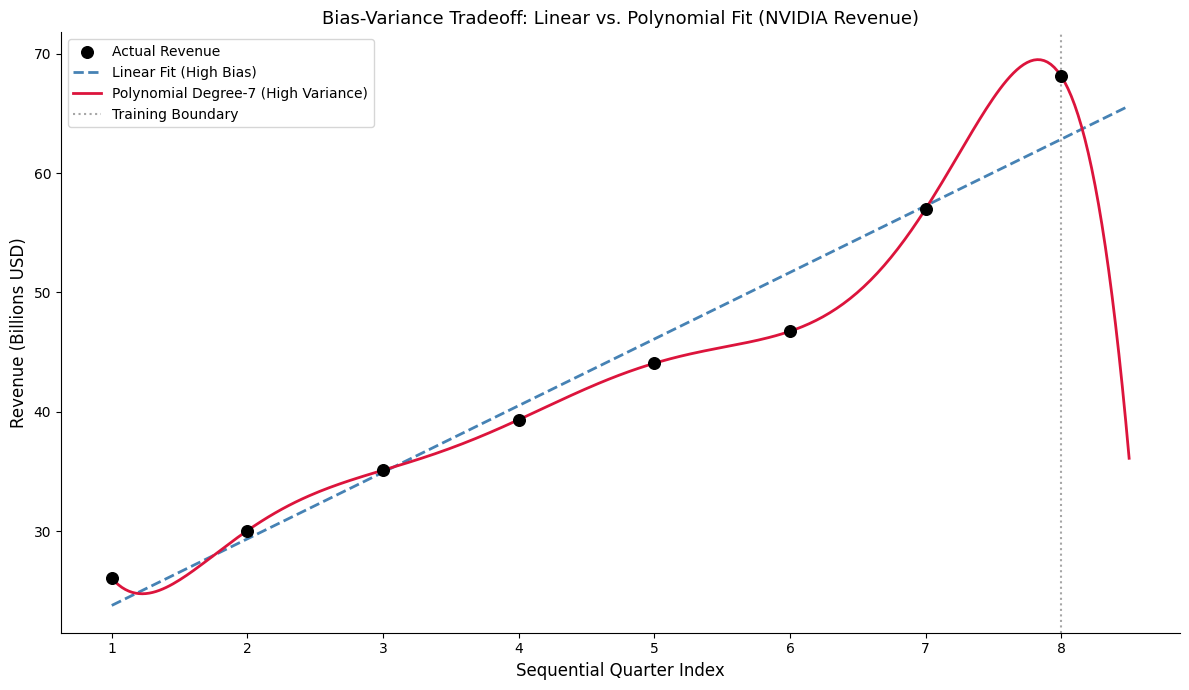

In [5]:
# 综合可视化：线性 vs 7阶多项式
X_smooth = np.linspace(1, 8.5, 300).reshape(-1, 1)
X_smooth_poly = poly_features.transform(X_smooth)
y_smooth_poly = poly_reg.predict(X_smooth_poly)
y_smooth_linear = lin_reg.predict(X_smooth)

plt.figure(figsize=(12, 7))
plt.scatter(X, y, color='black', zorder=5, s=70, label='Actual Revenue')
plt.plot(X_smooth, y_smooth_linear, color='steelblue', linestyle='--',
         linewidth=2, label='Linear Fit (High Bias)')
plt.plot(X_smooth, y_smooth_poly, color='crimson', linewidth=2,
         label='Polynomial Degree-7 (High Variance)')
plt.axvline(x=8, color='gray', linestyle=':', alpha=0.7, label='Training Boundary')
plt.title('Bias-Variance Tradeoff: Linear vs. Polynomial Fit (NVIDIA Revenue)', fontsize=13)
plt.xlabel('Sequential Quarter Index', fontsize=12)
plt.ylabel('Revenue (Billions USD)', fontsize=12)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Step 4: 认识论崩塌（外推预测）

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Hallucinated Q1 FY27 Revenue Prediction (Poly-7): $-84.00 Billion
Linear Q1 FY27 Prediction: $68.42 Billion
解读：7阶多项式在训练范围外产生幻觉预测，其末端轨迹由噪声驱动，导致灾难性外推失败。


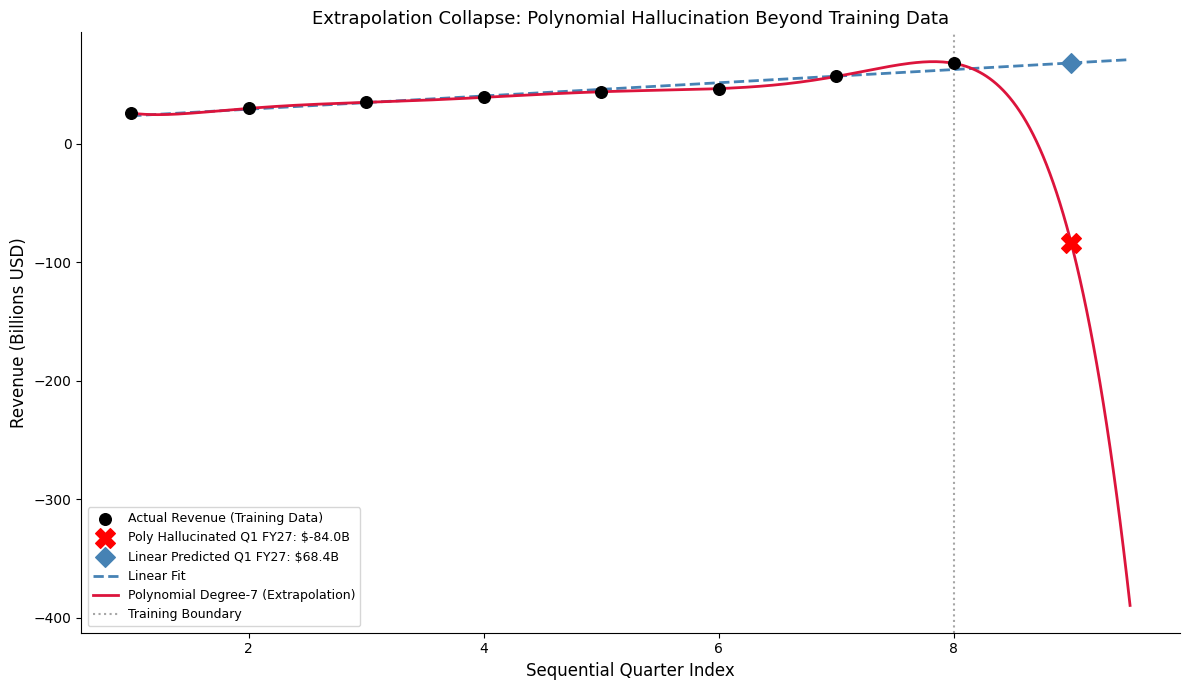

In [6]:
# Step 4: 外推崩塌 —— 预测Q1 FY27（时间索引=9）
X_future = np.array([[9]])
X_future_poly = poly_features.transform(X_future)
future_pred_poly = poly_reg.predict(X_future_poly)
future_pred_linear = lin_reg.predict(X_future)

print(f'Hallucinated Q1 FY27 Revenue Prediction (Poly-7): ${future_pred_poly[0]:.2f} Billion')
print(f'Linear Q1 FY27 Prediction: ${future_pred_linear[0]:.2f} Billion')
print('解读：7阶多项式在训练范围外产生幻觉预测，其末端轨迹由噪声驱动，导致灾难性外推失败。')

# 可视化外推崩塌
X_extrap = np.linspace(1, 9.5, 300).reshape(-1, 1)
X_extrap_poly = poly_features.transform(X_extrap)
y_extrap_poly = poly_reg.predict(X_extrap_poly)
y_extrap_linear = lin_reg.predict(X_extrap)

plt.figure(figsize=(12, 7))
plt.scatter(X, y, color='black', zorder=5, s=70, label='Actual Revenue (Training Data)')
plt.scatter([[9]], future_pred_poly, color='red', marker='X', s=200, zorder=6,
            label=f'Poly Hallucinated Q1 FY27: ${future_pred_poly[0]:.1f}B')
plt.scatter([[9]], future_pred_linear, color='steelblue', marker='D', s=100, zorder=6,
            label=f'Linear Predicted Q1 FY27: ${future_pred_linear[0]:.1f}B')
plt.plot(X_extrap, y_extrap_linear, color='steelblue', linestyle='--', linewidth=2, label='Linear Fit')
plt.plot(X_extrap, y_extrap_poly, color='crimson', linewidth=2, label='Polynomial Degree-7 (Extrapolation)')
plt.axvline(x=8, color='gray', linestyle=':', alpha=0.7, label='Training Boundary')
plt.title('Extrapolation Collapse: Polynomial Hallucination Beyond Training Data', fontsize=13)
plt.xlabel('Sequential Quarter Index', fontsize=12)
plt.ylabel('Revenue (Billions USD)', fontsize=12)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Step 5: K折交叉验证 —— 暴露真实方差

In [7]:
# Step 5: K折交叉验证（K=4）
# 7阶多项式
cv_scores_poly = cross_val_score(poly_reg, X_poly, y, cv=4, scoring='neg_mean_squared_error')
mean_cv_mse_poly = -cv_scores_poly.mean()

# 线性模型（对照）
cv_scores_linear = cross_val_score(lin_reg, X, y, cv=4, scoring='neg_mean_squared_error')
mean_cv_mse_linear = -cv_scores_linear.mean()

print(f'K-Fold Cross-Validated MSE (The True Operational Error): {mean_cv_mse_poly:.2f}')
print()
print('对比汇总:')
print(f'  线性模型 - 训练MSE: {mse_linear:.4f} | CV MSE: {mean_cv_mse_linear:.4f}')
print(f'  Poly-7  - 训练MSE: {mse_poly:.8f} | CV MSE: {mean_cv_mse_poly:.4f}')
print(f'  方差倍数放大: {mean_cv_mse_poly/mse_linear:.1f}x')
print()
print('结论：训练MSE接近0是虚假的成功幻觉，CV MSE暴露了模型的灾难性高方差。')

K-Fold Cross-Validated MSE (The True Operational Error): 8641.58

对比汇总:
  线性模型 - 训练MSE: 7.9139 | CV MSE: 34.5817
  Poly-7  - 训练MSE: 0.00000000 | CV MSE: 8641.5800
  方差倍数放大: 1091.9x

结论：训练MSE接近0是虚假的成功幻觉，CV MSE暴露了模型的灾难性高方差。


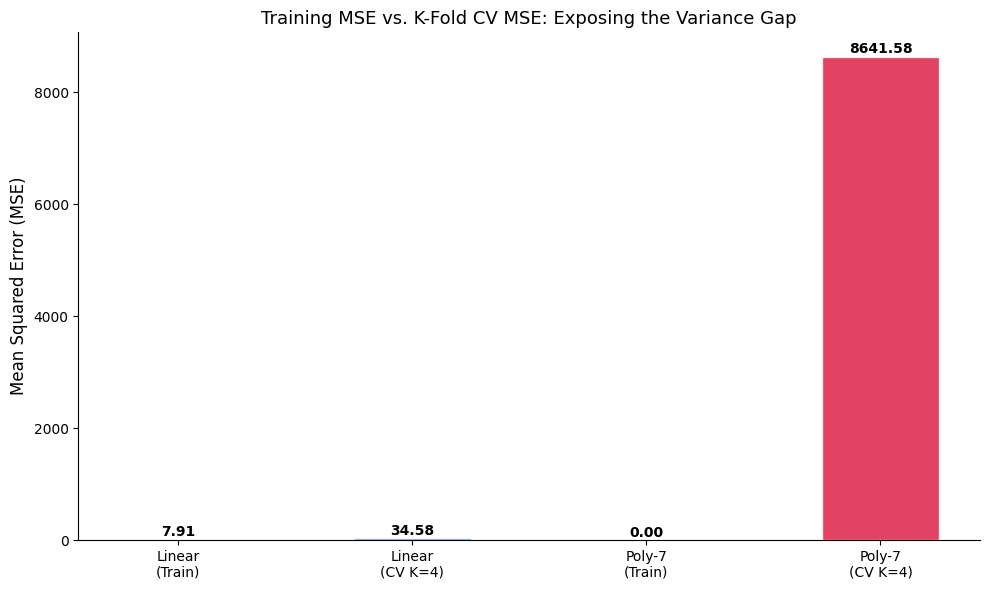

In [8]:
# 可视化：MSE对比条形图
labels = ['Linear\n(Train)', 'Linear\n(CV K=4)', 'Poly-7\n(Train)', 'Poly-7\n(CV K=4)']
values = [mse_linear, mean_cv_mse_linear, mse_poly, mean_cv_mse_poly]
colors = ['steelblue', 'steelblue', 'crimson', 'crimson']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, values, color=colors, alpha=0.8, edgecolor='white', width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Training MSE vs. K-Fold CV MSE: Exposing the Variance Gap', fontsize=13)
ax.set_ylabel('Mean Squared Error (MSE)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## AI-Assisted Expansion: Ridge Regularization (L2) with Automated Hyperparameter Tuning

In [9]:
# AI扩展：Ridge L2正则化 + RidgeCV自动超参数调优
#
# Ridge原理：
#   OLS最小化:   ||y - X*beta||^2
#   Ridge最小化: ||y - X*beta||^2 + alpha * ||beta||^2
#
# L2惩罚项 alpha*||beta||^2 强制系数向零收缩：
#   alpha大 -> 更强压缩 -> 更平滑曲线（减少方差，增加偏差）
#   alpha小 -> 弱压缩   -> 接近OLS（增加方差，减少偏差）

# 使用RidgeCV在对数间隔的alpha网格上自动搜索最优惩罚参数（4折CV）
alphas_to_test = np.logspace(-3, 5, 100)

ridge_cv_model = RidgeCV(
    alphas=alphas_to_test,
    cv=4,
    scoring='neg_mean_squared_error'
)
ridge_cv_model.fit(X_poly, y)  # 在多项式特征上拟合Ridge

optimal_alpha = ridge_cv_model.alpha_
print(f'RidgeCV自动选择的最优alpha: {optimal_alpha:.4f}')
print()
print('Ridge系数（已被L2惩罚压缩至接近零）:')
for i, (rc, oc) in enumerate(zip(ridge_cv_model.coef_, poly_reg.coef_)):
    print(f'  degree {i+1}: Ridge={rc:12.4f} | OLS={oc:15.4f}')

RidgeCV自动选择的最优alpha: 19.1791

Ridge系数（已被L2惩罚压缩至接近零）:
  degree 1: Ridge=      0.0371 | OLS=      -256.4349
  degree 2: Ridge=      0.1084 | OLS=       249.2455
  degree 3: Ridge=      0.2155 | OLS=      -121.3472
  degree 4: Ridge=      0.2502 | OLS=        33.0058
  degree 5: Ridge=     -0.1237 | OLS=        -5.0644
  degree 6: Ridge=      0.0184 | OLS=         0.4087
  degree 7: Ridge=     -0.0009 | OLS=        -0.0134


In [10]:
# Ridge评估：训练MSE vs K-Fold CV MSE
y_pred_ridge = ridge_cv_model.predict(X_poly)
mse_ridge_train = mean_squared_error(y, y_pred_ridge)

# 使用Pipeline确保每折都进行多项式变换（避免数据泄露）
ridge_pipeline = make_pipeline(
    PolynomialFeatures(degree=7, include_bias=False),
    Ridge(alpha=optimal_alpha)
)
cv_scores_ridge = cross_val_score(ridge_pipeline, X, y, cv=4, scoring='neg_mean_squared_error')
mean_cv_mse_ridge = -cv_scores_ridge.mean()

print('=' * 60)
print(f'正则化效果对比（Optimal alpha = {optimal_alpha:.4f}）')
print('=' * 60)
print(f'{"Model":<38} {"Train MSE":>10} {"CV MSE":>10}')
print('-' * 60)
print(f'{"Linear":<38} {mse_linear:>10.4f} {mean_cv_mse_linear:>10.4f}')
print(f'{"Poly-7 OLS (no regularization)":<38} {mse_poly:>10.6f} {mean_cv_mse_poly:>10.4f}')
print(f'{"Ridge L2 (alpha={:.4f})".format(optimal_alpha):<38} {mse_ridge_train:>10.4f} {mean_cv_mse_ridge:>10.4f}')
print('=' * 60)
print()
print('解读：Ridge用少量偏差（Train MSE略升）换取大幅方差降低（CV MSE显著下降）。')
print('这正是偏差-方差权衡的核心：正则化是提升预测稳定性的关键机制。')

正则化效果对比（Optimal alpha = 19.1791）
Model                                   Train MSE     CV MSE
------------------------------------------------------------
Linear                                     7.9139    34.5817
Poly-7 OLS (no regularization)           0.000000  8641.5800
Ridge L2 (alpha=19.1791)                   0.2646    15.3668

解读：Ridge用少量偏差（Train MSE略升）换取大幅方差降低（CV MSE显著下降）。
这正是偏差-方差权衡的核心：正则化是提升预测稳定性的关键机制。


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


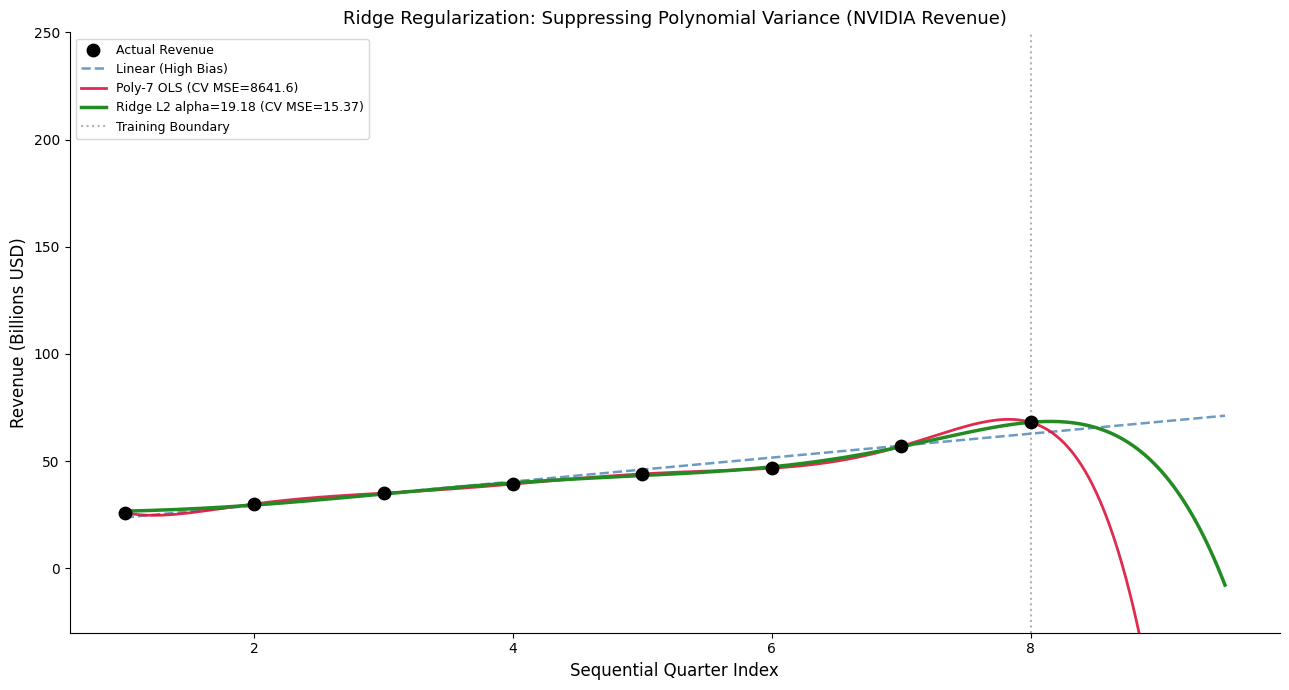

In [11]:
# 最终综合可视化：线性 vs Poly-7 OLS vs Ridge L2
X_plot = np.linspace(1, 9.5, 300).reshape(-1, 1)
X_plot_poly = poly_features.transform(X_plot)

y_plot_linear = lin_reg.predict(X_plot)
y_plot_ols = poly_reg.predict(X_plot_poly)
y_plot_ridge = ridge_cv_model.predict(X_plot_poly)

plt.figure(figsize=(13, 7))
plt.scatter(X, y, color='black', zorder=5, s=80, label='Actual Revenue')
plt.plot(X_plot, y_plot_linear, color='steelblue', linestyle='--',
         linewidth=1.8, label='Linear (High Bias)', alpha=0.8)
plt.plot(X_plot, y_plot_ols, color='crimson', linewidth=2,
         label=f'Poly-7 OLS (CV MSE={mean_cv_mse_poly:.1f})', alpha=0.9)
plt.plot(X_plot, y_plot_ridge, color='forestgreen', linewidth=2.5,
         label=f'Ridge L2 alpha={optimal_alpha:.2f} (CV MSE={mean_cv_mse_ridge:.2f})')
plt.axvline(x=8, color='gray', linestyle=':', alpha=0.6, label='Training Boundary')
plt.ylim(-30, 250)
plt.title('Ridge Regularization: Suppressing Polynomial Variance (NVIDIA Revenue)', fontsize=13)
plt.xlabel('Sequential Quarter Index', fontsize=12)
plt.ylabel('Revenue (Billions USD)', fontsize=12)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()